In [22]:
RICCI_SYNC_DIR = "../Q_Recon_ricci"

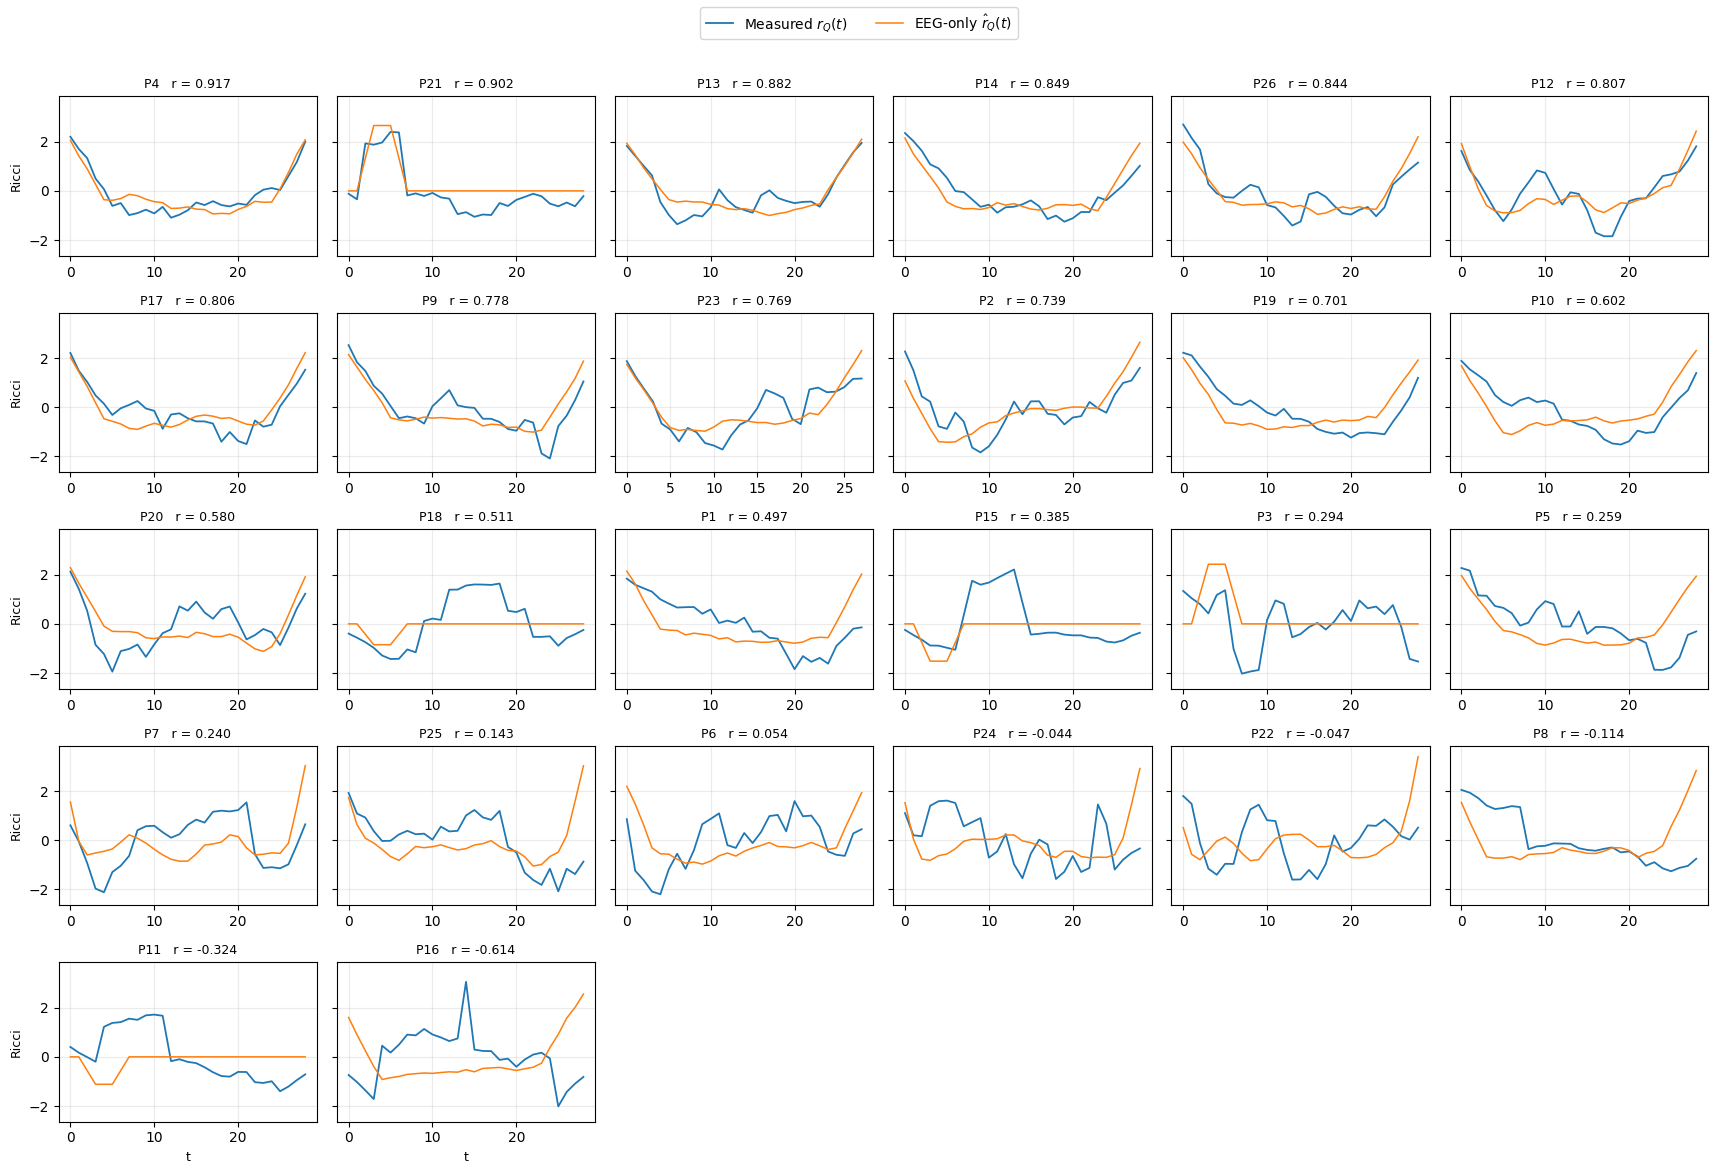


Sessions (sorted by Pearson):
  P4   r = 0.916858   n = 29
 P21   r = 0.902318   n = 29
 P13   r = 0.882436   n = 29
 P14   r = 0.848817   n = 29
 P26   r = 0.844089   n = 29
 P12   r = 0.806768   n = 29
 P17   r = 0.805991   n = 29
  P9   r = 0.778134   n = 29
 P23   r = 0.768999   n = 28
  P2   r = 0.739338   n = 29
 P19   r = 0.700814   n = 29
 P10   r = 0.601783   n = 29
 P20   r = 0.580241   n = 29
 P18   r = 0.511156   n = 29
  P1   r = 0.497178   n = 29
 P15   r = 0.384730   n = 29
  P3   r = 0.294475   n = 29
  P5   r = 0.259197   n = 29
  P7   r = 0.239911   n = 29
 P25   r = 0.142888   n = 29
  P6   r = 0.053741   n = 29
 P24   r = -0.043618   n = 29
 P22   r = -0.046778   n = 29
  P8   r = -0.114217   n = 29
 P11   r = -0.323751   n = 29
 P16   r = -0.614055   n = 29

Summary:
mean Pearson   = 0.439132
median Pearson = 0.545698
max Pearson    = 0.916858
min Pearson    = -0.614055


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =====================================================
# paths / params (latest final model)
# =====================================================

FIXED_LAG = -1

# latest final model
AMP_SCALE = 4.0
LAMBDA_SHIFT = 0.4
LAMBDA_SCALE = 0.6
WIDTH_FRAC = 0.15

# bump detected -> fixed params
BUMP_S_THR = 0.8
FIX_C = 4
FIX_W = 8
FIX_AMP_SCALE = 1.0
FIX_LAM = 1.0

# =====================================================
# helpers
# =====================================================
def zscore(x):
    x = np.asarray(x, dtype=float)
    m = np.isfinite(x)
    y = np.full_like(x, np.nan, dtype=float)
    if m.sum() < 2:
        return y
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    y[m] = 0.0 if sd < 1e-12 else (x[m] - mu) / sd
    return y

def shift(x, lag):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    if lag < 0:
        y[:-(-lag)] = x[-lag:]
    elif lag > 0:
        y[lag:] = x[:-lag]
    else:
        y[:] = x
    return y

def d2(x):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    if len(x) >= 3:
        y[1:-1] = x[2:] - 2 * x[1:-1] + x[:-2]
    return y

def corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    if np.nanstd(x[m]) < 1e-12 or np.nanstd(y[m]) < 1e-12:
        return np.nan
    return pearsonr(x[m], y[m])[0]

# =====================================================
# latest model pieces
# =====================================================
def bump_features(E):
    n = len(E)
    t = np.arange(n, dtype=float)

    coef = np.polyfit(t, E, 2)
    fit = np.polyval(coef, t)
    resid = E - fit

    c = int(np.nanargmax(np.abs(resid)))
    w = max(2, int(n * WIDTH_FRAC))

    lo = max(0, c - w)
    hi = min(n, c + w)

    C3 = np.nansum(resid[lo:hi])
    total = np.nansum(np.abs(resid))
    local = np.nansum(np.abs(resid[lo:hi]))
    C4 = local / (total + 1e-8)

    return c, w, resid, C3, C4

def make_pulse(n, c, w, a, s):
    bump = np.zeros(n, dtype=float)

    rise = max(1, int(0.25 * w))
    hold = max(1, int(0.35 * w))
    fall = max(1, int(0.25 * w))

    start = max(0, c - (rise + hold // 2))
    up = min(n, start + rise)
    mid = min(n, up + hold)
    end = min(n, mid + fall)

    if up > start:
        bump[start:up] = s * np.linspace(0, a, up - start, endpoint=False)
    if mid > up:
        bump[up:mid] = s * a
    if end > mid:
        bump[mid:end] = s * np.linspace(a, 0, end - mid, endpoint=False)

    return bump

# =====================================================
# load latest data
# =====================================================
cache = {}
for f in os.listdir(RICCI_SYNC_DIR):
    if not f.endswith("_timeseries.csv"):
        continue
    label = f.replace("_timeseries.csv", "")
    df_tmp = pd.read_csv(os.path.join(RICCI_SYNC_DIR, f))
    cache[label] = {
        "E": zscore(df_tmp["E_Ricci"].values),
        "Q": zscore(df_tmp["Q_Ricci_raw"].values),
    }

labels = sorted(cache.keys())

# =====================================================
# meta build from latest model
# =====================================================
meta_rows = []
for label in labels:
    E = cache[label]["E"]
    _, _, _, C3, C4 = bump_features(E)
    meta_rows.append({"label": label, "C3": C3, "C4": C4})

meta = pd.DataFrame(meta_rows)
meta["C3_z"] = (meta["C3"] - meta["C3"].mean()) / (meta["C3"].std() + 1e-8)
meta["C4_z"] = (meta["C4"] - meta["C4"].mean()) / (meta["C4"].std() + 1e-8)
meta["S"] = meta["C3_z"] + meta["C4_z"]
meta = meta.set_index("label")

# =====================================================
# latest reconstruction
# =====================================================
def reconstruct_latest(label):
    E = cache[label]["E"]
    Q = cache[label]["Q"]

    base = shift(E, FIXED_LAG)
    alpha = 0.5 * np.nanmean(np.abs(d2(E)))
    base_pred = base + alpha * np.nan_to_num(d2(base), nan=0.0)

    c, w, resid, C3, C4 = bump_features(E)
    S = float(meta.loc[label, "S"])

    is_bump = S > BUMP_S_THR

    if is_bump:
        c_use = FIX_C
        w_use = FIX_W
        amp = FIX_AMP_SCALE * np.nanmax(np.abs(resid))
        lam = FIX_LAM
    else:
        c_use = c
        w_use = w
        amp = AMP_SCALE * np.nanmax(np.abs(resid))
        lam = np.clip((S - LAMBDA_SHIFT) / LAMBDA_SCALE, 0, 1)

    s = np.sign(C3)
    if s == 0:
        s = 1.0

    bump = make_pulse(len(E), c_use, w_use, amp, s)
    pred = (1 - lam) * base_pred + lam * bump

    m = np.isfinite(Q) & np.isfinite(pred)
    qv = Q[m]
    pv = pred[m]

    return {
        "label": label,
        "Q": qv,
        "pred": pv,
        "pearson": pearsonr(qv, pv)[0] if len(qv) >= 10 else np.nan,
        "n": int(m.sum()),
        "S": S,
        "bump_detected": is_bump,
    }

# =====================================================
# all sessions
# =====================================================
all_results = []
for label in labels:
    all_results.append(reconstruct_latest(label))

# =====================================================
# sort by Pearson (descending)
# =====================================================
panel_data = sorted(all_results, key=lambda d: d["pearson"], reverse=True)

# =====================================================
# summary stats
# =====================================================
df_res = pd.DataFrame(panel_data)

mean_r = df_res["pearson"].mean()
median_r = df_res["pearson"].median()

# =====================================================
# global y-limits for comparability
# =====================================================
all_vals = np.concatenate(
    [np.concatenate([d["Q"], d["pred"]]) for d in panel_data if d["n"] > 0]
)
ymin = np.nanmin(all_vals)
ymax = np.nanmax(all_vals)
pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.5
ylims = (ymin - pad, ymax + pad)

# =====================================================
# figure: 5 x 6
# =====================================================
nrows, ncols = 5, 6
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, 12),
    sharex=False,
    sharey=True
)
axes = axes.flatten()

for ax, d in zip(axes, panel_data):
    x = np.arange(len(d["Q"]))

    ax.plot(x, d["Q"], linewidth=1.3, label=r"Measured $r_Q(t)$")
    ax.plot(x, d["pred"], linewidth=1.1, label=r"EEG-only $\hat{r}_Q(t)$")

    r_txt = "nan" if not np.isfinite(d["pearson"]) else f'{d["pearson"]:.3f}'
    ax.set_title(f'{d["label"]}   r = {r_txt}', fontsize=9)
    ax.set_ylim(*ylims)
    ax.grid(True, alpha=0.25)

# 余り軸を消す
for ax in axes[len(panel_data):]:
    ax.axis("off")

# yラベル（左列）
for row in range(nrows):
    idx = row * ncols
    if idx < len(axes):
        axes[idx].set_ylabel("Ricci", fontsize=9)

# xラベル（最下段）
for idx in range((nrows - 1) * ncols, nrows * ncols):
    if idx < len(axes):
        axes[idx].set_xlabel("t", fontsize=9)

# legendは上に1つだけ
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc="upper center", ncol=2, frameon=True)

fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.95])

plt.show()

# =====================================================
# print ranked sessions
# =====================================================
print()
print("Sessions (sorted by Pearson):")
for d in panel_data:
    print(f'{d["label"]:>4s}   r = {d["pearson"]:.6f}   n = {d["n"]}')

print()
print("Summary:")
print(f"mean Pearson   = {mean_r:.6f}")
print(f"median Pearson = {median_r:.6f}")
print(f"max Pearson    = {df_res['pearson'].max():.6f}")
print(f"min Pearson    = {df_res['pearson'].min():.6f}")

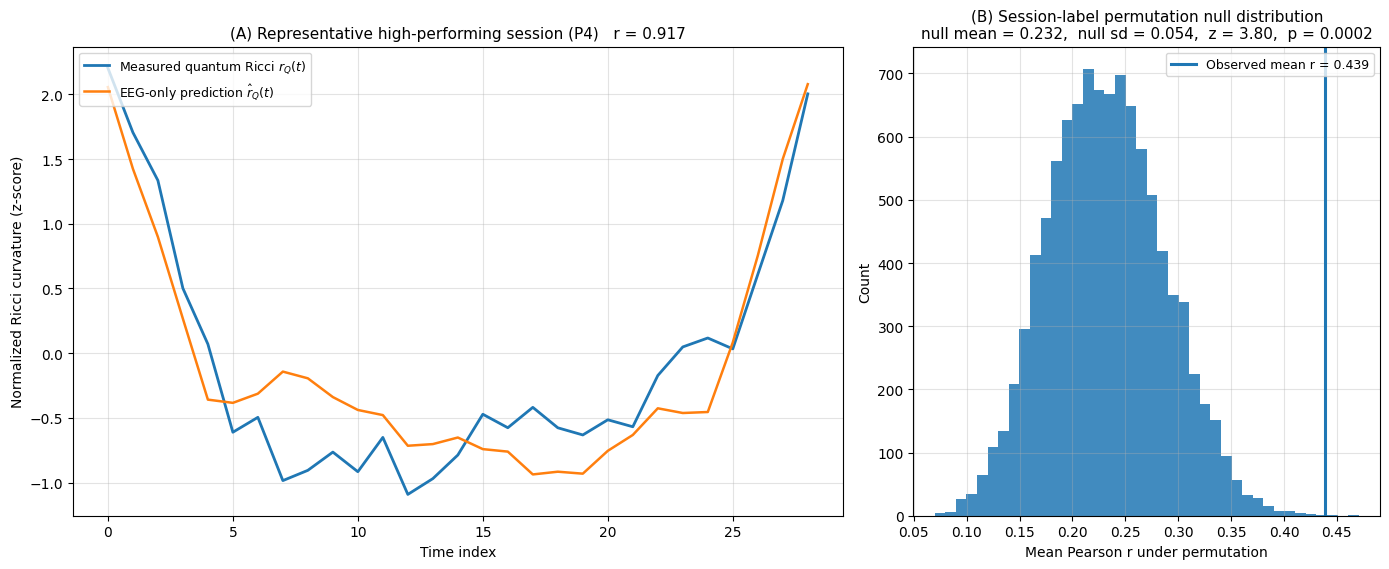

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =====================================================
# paths / params (latest final model)
# =====================================================

N_PERM = 10000

FIXED_LAG = -1

# latest final model
AMP_SCALE = 4.0
LAMBDA_SHIFT = 0.4
LAMBDA_SCALE = 0.6
WIDTH_FRAC = 0.15

# bump detected -> fixed params
BUMP_S_THR = 0.8
FIX_C = 4
FIX_W = 8
FIX_AMP_SCALE = 1.0
FIX_LAM = 1.0

REP_LABEL = "P4"

# =====================================================
# helpers
# =====================================================
def zscore(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    y = np.full_like(x, np.nan)
    if m.sum() < 2:
        return y
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    y[m] = 0 if sd < 1e-12 else (x[m] - mu) / sd
    return y

def shift(x, lag):
    x = np.asarray(x, float)
    y = np.full_like(x, np.nan)
    if lag < 0:
        y[:-(-lag)] = x[-lag:]
    elif lag > 0:
        y[lag:] = x[:-lag]
    else:
        y[:] = x
    return y

def d2(x):
    x = np.asarray(x, float)
    y = np.full_like(x, np.nan)
    if len(x) >= 3:
        y[1:-1] = x[2:] - 2 * x[1:-1] + x[:-2]
    return y

def corr(x, y):
    n = min(len(x), len(y))
    x = np.asarray(x[:n], float)
    y = np.asarray(y[:n], float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    if np.nanstd(x[m]) < 1e-12 or np.nanstd(y[m]) < 1e-12:
        return np.nan
    return pearsonr(x[m], y[m])[0]

# =====================================================
# latest model pieces
# =====================================================
def bump_features(E):
    n = len(E)
    t = np.arange(n, dtype=float)

    coef = np.polyfit(t, E, 2)
    fit = np.polyval(coef, t)
    resid = E - fit

    c = int(np.nanargmax(np.abs(resid)))
    w = max(2, int(n * WIDTH_FRAC))

    lo = max(0, c - w)
    hi = min(n, c + w)

    C3 = np.nansum(resid[lo:hi])
    total = np.nansum(np.abs(resid))
    local = np.nansum(np.abs(resid[lo:hi]))
    C4 = local / (total + 1e-8)

    return c, w, resid, C3, C4

def make_pulse(n, c, w, a, s):
    bump = np.zeros(n, dtype=float)

    rise = max(1, int(0.25 * w))
    hold = max(1, int(0.35 * w))
    fall = max(1, int(0.25 * w))

    start = max(0, c - (rise + hold // 2))
    up = min(n, start + rise)
    mid = min(n, up + hold)
    end = min(n, mid + fall)

    if up > start:
        bump[start:up] = s * np.linspace(0, a, up - start, endpoint=False)
    if mid > up:
        bump[up:mid] = s * a
    if end > mid:
        bump[mid:end] = s * np.linspace(a, 0, end - mid, endpoint=False)

    return bump

# =====================================================
# load latest data
# =====================================================
cache = {}
for f in os.listdir(RICCI_SYNC_DIR):
    if not f.endswith("_timeseries.csv"):
        continue
    label = f.replace("_timeseries.csv", "")
    df = pd.read_csv(os.path.join(RICCI_SYNC_DIR, f))
    cache[label] = {
        "E": zscore(df["E_Ricci"].values),
        "Q": zscore(df["Q_Ricci_raw"].values),
    }

labels = sorted(cache.keys())

if REP_LABEL not in labels:
    raise ValueError(f"{REP_LABEL} not found in {RICCI_SYNC_DIR}")

# =====================================================
# meta build from latest model
# =====================================================
meta_rows = []
for label in labels:
    E = cache[label]["E"]
    _, _, _, C3, C4 = bump_features(E)
    meta_rows.append({"label": label, "C3": C3, "C4": C4})

meta = pd.DataFrame(meta_rows)
meta["C3_z"] = (meta["C3"] - meta["C3"].mean()) / (meta["C3"].std() + 1e-8)
meta["C4_z"] = (meta["C4"] - meta["C4"].mean()) / (meta["C4"].std() + 1e-8)
meta["S"] = meta["C3_z"] + meta["C4_z"]
meta = meta.set_index("label")

# =====================================================
# latest reconstruction
# =====================================================
def reconstruct_latest(label):
    E = cache[label]["E"]
    Q = cache[label]["Q"]

    base = shift(E, FIXED_LAG)
    alpha = 0.5 * np.nanmean(np.abs(d2(E)))
    base_pred = base + alpha * np.nan_to_num(d2(base), nan=0.0)

    c, w, resid, C3, C4 = bump_features(E)
    S = float(meta.loc[label, "S"])

    is_bump = S > BUMP_S_THR

    if is_bump:
        c_use = FIX_C
        w_use = FIX_W
        amp = FIX_AMP_SCALE * np.nanmax(np.abs(resid))
        lam = FIX_LAM
    else:
        c_use = c
        w_use = w
        amp = AMP_SCALE * np.nanmax(np.abs(resid))
        lam = np.clip((S - LAMBDA_SHIFT) / LAMBDA_SCALE, 0, 1)

    s = np.sign(C3)
    if s == 0:
        s = 1.0

    bump = make_pulse(len(E), c_use, w_use, amp, s)
    pred = (1 - lam) * base_pred + lam * bump

    m = np.isfinite(Q) & np.isfinite(pred)
    return {
        "Q": Q[m],
        "pred": pred[m],
        "pearson": pearsonr(Q[m], pred[m])[0],
        "n": int(m.sum()),
        "S": S,
        "bump_detected": is_bump,
    }

# representative session
rep = reconstruct_latest(REP_LABEL)

# =====================================================
# observed mean
# =====================================================
obs_vals = []
for label in labels:
    obs_vals.append(reconstruct_latest(label)["pearson"])
obs_vals = np.asarray(obs_vals, float)
obs_mean_r = float(np.nanmean(obs_vals))

# =====================================================
# latest label permutation null
# =====================================================
# precompute predictions for speed
pred_cache = {}
for label in labels:
    pred_cache[label] = reconstruct_latest(label)["pred"]

null_vals = np.zeros(N_PERM, dtype=float)

for i in range(N_PERM):
    shuffled = np.random.permutation(labels)
    rs = []
    for l_pred, l_q in zip(labels, shuffled):
        rs.append(corr(cache[l_q]["Q"], pred_cache[l_pred]))
    null_vals[i] = np.nanmean(rs)

null_mean = float(np.mean(null_vals))
null_sd = float(np.std(null_vals))
p_value = float(np.mean(null_vals >= obs_mean_r))
z_null = (obs_mean_r - null_mean) / null_sd if null_sd > 0 else np.nan

# =====================================================
# figure
# =====================================================
fig = plt.figure(figsize=(14, 5.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.65, 1.0])

# -------------------------
# Panel A: representative P4
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(rep["Q"]))

ax1.plot(x, rep["Q"], linewidth=2.0, label=r"Measured quantum Ricci $r_Q(t)$")
ax1.plot(x, rep["pred"], linewidth=1.8, label=r"EEG-only prediction $\hat{r}_Q(t)$")

ax1.set_title(
    f"(A) Representative high-performing session ({REP_LABEL})   "
    f"r = {rep['pearson']:.3f}",
    fontsize=11
)
ax1.set_xlabel("Time index")
ax1.set_ylabel("Normalized Ricci curvature (z-score)")
ax1.grid(True, alpha=0.35)
ax1.legend(loc="upper left", fontsize=9, frameon=True)

# -------------------------
# Panel B: latest permutation null
# -------------------------
ax2 = fig.add_subplot(gs[0, 1])

ax2.hist(null_vals, bins=40, alpha=0.85)
ax2.axvline(obs_mean_r, linewidth=2.2, label=f"Observed mean r = {obs_mean_r:.3f}")

ax2.set_title(
    "(B) Session-label permutation null distribution\n"
    f"null mean = {null_mean:.3f},  null sd = {null_sd:.3f},  "
    f"z = {z_null:.2f},  p = {p_value:.4g}",
    fontsize=11
)
ax2.set_xlabel("Mean Pearson r under permutation")
ax2.set_ylabel("Count")
ax2.grid(True, alpha=0.35)
ax2.legend(loc="upper right", fontsize=9, frameon=True)

fig.tight_layout(rect=[0, 0, 1, 1])


plt.show()


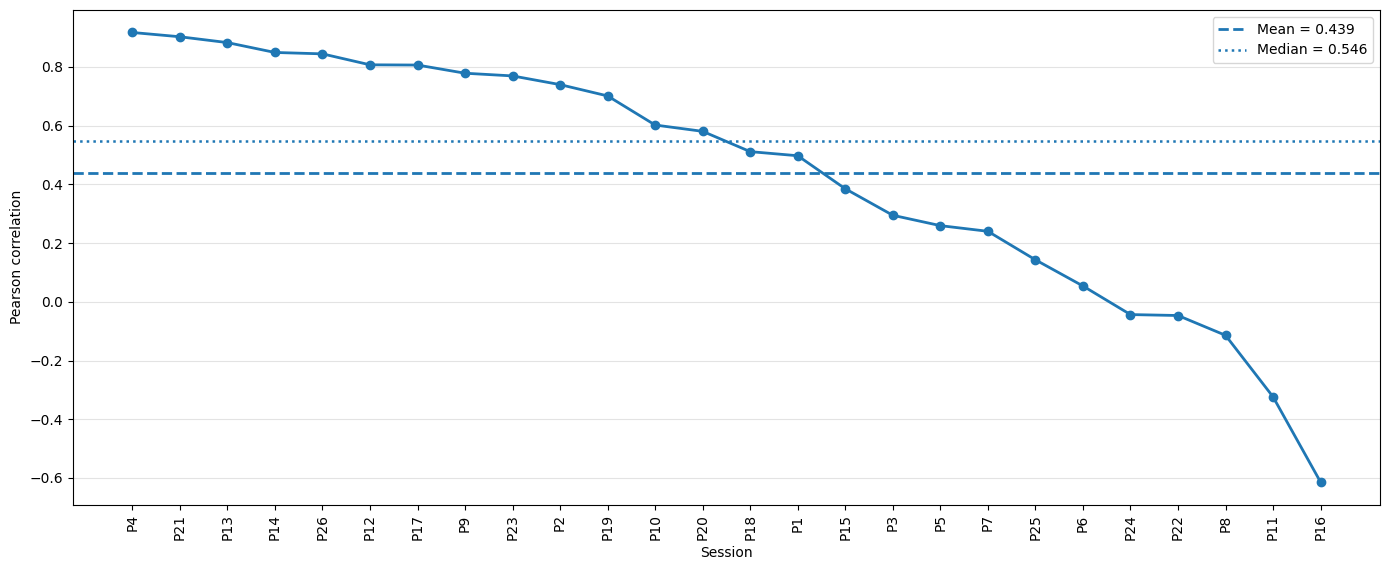


Summary:
mean Pearson   = 0.439132
median Pearson = 0.545698
max Pearson    = 0.916858
min Pearson    = -0.614055


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =====================================================
# paths / params (latest final model)
# =====================================================

FIXED_LAG = -1

# latest final model
AMP_SCALE = 4.0
LAMBDA_SHIFT = 0.4
LAMBDA_SCALE = 0.6
WIDTH_FRAC = 0.15

# bump detected -> fixed params
BUMP_S_THR = 0.8
FIX_C = 4
FIX_W = 8
FIX_AMP_SCALE = 1.0
FIX_LAM = 1.0

# =====================================================
# helpers
# =====================================================
def zscore(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    y = np.full_like(x, np.nan)
    if m.sum() < 2:
        return y
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    y[m] = 0 if sd < 1e-12 else (x[m] - mu) / sd
    return y

def shift(x, lag):
    x = np.asarray(x, float)
    y = np.full_like(x, np.nan)
    if lag < 0:
        y[:-(-lag)] = x[-lag:]
    elif lag > 0:
        y[lag:] = x[:-lag]
    else:
        y[:] = x
    return y

def d2(x):
    x = np.asarray(x, float)
    y = np.full_like(x, np.nan)
    if len(x) >= 3:
        y[1:-1] = x[2:] - 2 * x[1:-1] + x[:-2]
    return y

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    if np.nanstd(x[m]) < 1e-12 or np.nanstd(y[m]) < 1e-12:
        return np.nan
    return pearsonr(x[m], y[m])[0]

# =====================================================
# latest model pieces
# =====================================================
def bump_features(E):
    n = len(E)
    t = np.arange(n, dtype=float)

    coef = np.polyfit(t, E, 2)
    fit = np.polyval(coef, t)
    resid = E - fit

    c = int(np.nanargmax(np.abs(resid)))
    w = max(2, int(n * WIDTH_FRAC))

    lo = max(0, c - w)
    hi = min(n, c + w)

    C3 = np.nansum(resid[lo:hi])
    total = np.nansum(np.abs(resid))
    local = np.nansum(np.abs(resid[lo:hi]))
    C4 = local / (total + 1e-8)

    return c, w, resid, C3, C4

def make_pulse(n, c, w, a, s):
    bump = np.zeros(n, dtype=float)

    rise = max(1, int(0.25 * w))
    hold = max(1, int(0.35 * w))
    fall = max(1, int(0.25 * w))

    start = max(0, c - (rise + hold // 2))
    up = min(n, start + rise)
    mid = min(n, up + hold)
    end = min(n, mid + fall)

    if up > start:
        bump[start:up] = s * np.linspace(0, a, up - start, endpoint=False)
    if mid > up:
        bump[up:mid] = s * a
    if end > mid:
        bump[mid:end] = s * np.linspace(a, 0, end - mid, endpoint=False)

    return bump

# =====================================================
# load latest data
# =====================================================
cache = {}
for f in os.listdir(RICCI_SYNC_DIR):
    if not f.endswith("_timeseries.csv"):
        continue
    label = f.replace("_timeseries.csv", "")
    df = pd.read_csv(os.path.join(RICCI_SYNC_DIR, f))
    cache[label] = {
        "E": zscore(df["E_Ricci"].values),
        "Q": zscore(df["Q_Ricci_raw"].values),
    }

labels = sorted(cache.keys())

# =====================================================
# meta build from latest model
# =====================================================
meta_rows = []
for label in labels:
    E = cache[label]["E"]
    _, _, _, C3, C4 = bump_features(E)
    meta_rows.append({"label": label, "C3": C3, "C4": C4})

meta = pd.DataFrame(meta_rows)
meta["C3_z"] = (meta["C3"] - meta["C3"].mean()) / (meta["C3"].std() + 1e-8)
meta["C4_z"] = (meta["C4"] - meta["C4"].mean()) / (meta["C4"].std() + 1e-8)
meta["S"] = meta["C3_z"] + meta["C4_z"]
meta = meta.set_index("label")

# =====================================================
# latest reconstruction results
# =====================================================
rows = []

for label in labels:
    E = cache[label]["E"]
    Q = cache[label]["Q"]

    base = shift(E, FIXED_LAG)
    alpha = 0.5 * np.nanmean(np.abs(d2(E)))
    base_pred = base + alpha * np.nan_to_num(d2(base), nan=0.0)

    c, w, resid, C3, C4 = bump_features(E)
    S = float(meta.loc[label, "S"])

    is_bump = S > BUMP_S_THR

    if is_bump:
        c_use = FIX_C
        w_use = FIX_W
        amp = FIX_AMP_SCALE * np.nanmax(np.abs(resid))
        lam = FIX_LAM
    else:
        c_use = c
        w_use = w
        amp = AMP_SCALE * np.nanmax(np.abs(resid))
        lam = np.clip((S - LAMBDA_SHIFT) / LAMBDA_SCALE, 0, 1)

    s = np.sign(C3)
    if s == 0:
        s = 1.0

    bump = make_pulse(len(E), c_use, w_use, amp, s)
    pred = (1 - lam) * base_pred + lam * bump

    rows.append({
        "label": label,
        "S": S,
        "bump_detected": is_bump,
        "pearson": corr(Q, pred),
    })

df = pd.DataFrame(rows).sort_values("pearson", ascending=False).reset_index(drop=True)

mean_r = float(df["pearson"].mean())
median_r = float(df["pearson"].median())

# =====================================================
# figure
# =====================================================
fig, ax = plt.subplots(figsize=(14, 5.8))

x = np.arange(len(df))
ax.plot(x, df["pearson"], marker="o", linewidth=2.0)

ax.axhline(mean_r, linestyle="--", linewidth=2.0, label=f"Mean = {mean_r:.3f}")
ax.axhline(median_r, linestyle=":", linewidth=1.8, label=f"Median = {median_r:.3f}")

ax.set_xticks(x)
ax.set_xticklabels(df["label"], rotation=90)
ax.set_ylabel("Pearson correlation")
ax.set_xlabel("Session")
ax.grid(True, axis="y", alpha=0.35)
ax.legend(loc="upper right", frameon=True)

fig.tight_layout()

plt.show()


print()
print("Summary:")
print(f"mean Pearson   = {mean_r:.6f}")
print(f"median Pearson = {median_r:.6f}")
print(f"max Pearson    = {df['pearson'].max():.6f}")
print(f"min Pearson    = {df['pearson'].min():.6f}")

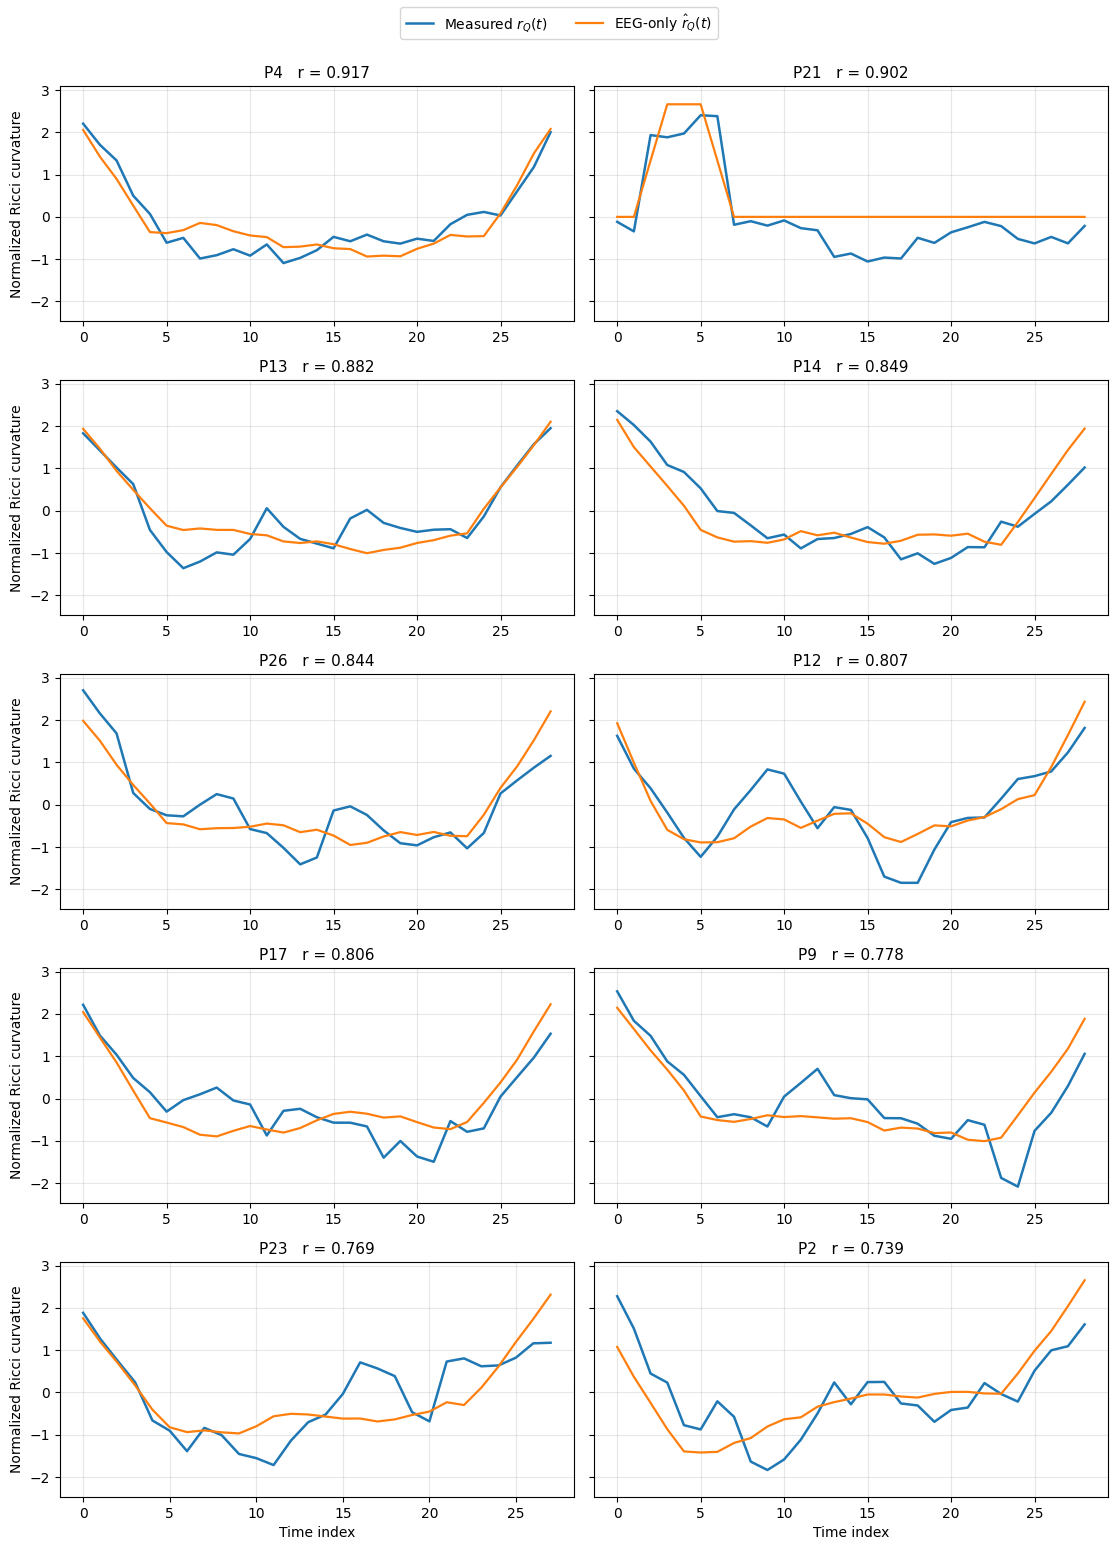


Top-10 sessions used:
  P4   r = 0.916858   n = 29
 P21   r = 0.902318   n = 29
 P13   r = 0.882436   n = 29
 P14   r = 0.848817   n = 29
 P26   r = 0.844089   n = 29
 P12   r = 0.806768   n = 29
 P17   r = 0.805991   n = 29
  P9   r = 0.778134   n = 29
 P23   r = 0.768999   n = 28
  P2   r = 0.739338   n = 29


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =====================================================
# paths / params (latest final model)
# =====================================================

FIXED_LAG = -1

# latest final model
AMP_SCALE = 4.0
LAMBDA_SHIFT = 0.4
LAMBDA_SCALE = 0.6
WIDTH_FRAC = 0.15

# bump detected -> fixed params
BUMP_S_THR = 0.8
FIX_C = 4
FIX_W = 8
FIX_AMP_SCALE = 1.0
FIX_LAM = 1.0

# =====================================================
# helpers
# =====================================================
def zscore(x):
    x = np.asarray(x, dtype=float)
    m = np.isfinite(x)
    y = np.full_like(x, np.nan, dtype=float)
    if m.sum() < 2:
        return y
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    y[m] = 0.0 if sd < 1e-12 else (x[m] - mu) / sd
    return y

def shift(x, lag):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    if lag < 0:
        y[:-(-lag)] = x[-lag:]
    elif lag > 0:
        y[lag:] = x[:-lag]
    else:
        y[:] = x
    return y

def d2(x):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    if len(x) >= 3:
        y[1:-1] = x[2:] - 2 * x[1:-1] + x[:-2]
    return y

def corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    if np.nanstd(x[m]) < 1e-12 or np.nanstd(y[m]) < 1e-12:
        return np.nan
    return pearsonr(x[m], y[m])[0]

# =====================================================
# latest model pieces
# =====================================================
def bump_features(E):
    n = len(E)
    t = np.arange(n, dtype=float)

    coef = np.polyfit(t, E, 2)
    fit = np.polyval(coef, t)
    resid = E - fit

    c = int(np.nanargmax(np.abs(resid)))
    w = max(2, int(n * WIDTH_FRAC))

    lo = max(0, c - w)
    hi = min(n, c + w)

    C3 = np.nansum(resid[lo:hi])
    total = np.nansum(np.abs(resid))
    local = np.nansum(np.abs(resid[lo:hi]))
    C4 = local / (total + 1e-8)

    return c, w, resid, C3, C4

def make_pulse(n, c, w, a, s):
    bump = np.zeros(n, dtype=float)

    rise = max(1, int(0.25 * w))
    hold = max(1, int(0.35 * w))
    fall = max(1, int(0.25 * w))

    start = max(0, c - (rise + hold // 2))
    up = min(n, start + rise)
    mid = min(n, up + hold)
    end = min(n, mid + fall)

    if up > start:
        bump[start:up] = s * np.linspace(0, a, up - start, endpoint=False)
    if mid > up:
        bump[up:mid] = s * a
    if end > mid:
        bump[mid:end] = s * np.linspace(a, 0, end - mid, endpoint=False)

    return bump

# =====================================================
# load latest data
# =====================================================
cache = {}
for f in os.listdir(RICCI_SYNC_DIR):
    if not f.endswith("_timeseries.csv"):
        continue
    label = f.replace("_timeseries.csv", "")
    df = pd.read_csv(os.path.join(RICCI_SYNC_DIR, f))
    cache[label] = {
        "E": zscore(df["E_Ricci"].values),
        "Q": zscore(df["Q_Ricci_raw"].values),
    }

labels = sorted(cache.keys())

# =====================================================
# meta build from latest model
# =====================================================
meta_rows = []
for label in labels:
    E = cache[label]["E"]
    _, _, _, C3, C4 = bump_features(E)
    meta_rows.append({"label": label, "C3": C3, "C4": C4})

meta = pd.DataFrame(meta_rows)
meta["C3_z"] = (meta["C3"] - meta["C3"].mean()) / (meta["C3"].std() + 1e-8)
meta["C4_z"] = (meta["C4"] - meta["C4"].mean()) / (meta["C4"].std() + 1e-8)
meta["S"] = meta["C3_z"] + meta["C4_z"]
meta = meta.set_index("label")

# =====================================================
# latest reconstruction
# =====================================================
def reconstruct_latest(label):
    E = cache[label]["E"]
    Q = cache[label]["Q"]

    base = shift(E, FIXED_LAG)
    alpha = 0.5 * np.nanmean(np.abs(d2(E)))
    base_pred = base + alpha * np.nan_to_num(d2(base), nan=0.0)

    c, w, resid, C3, C4 = bump_features(E)
    S = float(meta.loc[label, "S"])

    is_bump = S > BUMP_S_THR

    if is_bump:
        c_use = FIX_C
        w_use = FIX_W
        amp = FIX_AMP_SCALE * np.nanmax(np.abs(resid))
        lam = FIX_LAM
    else:
        c_use = c
        w_use = w
        amp = AMP_SCALE * np.nanmax(np.abs(resid))
        lam = np.clip((S - LAMBDA_SHIFT) / LAMBDA_SCALE, 0, 1)

    s = np.sign(C3)
    if s == 0:
        s = 1.0

    bump = make_pulse(len(E), c_use, w_use, amp, s)
    pred = (1 - lam) * base_pred + lam * bump

    m = np.isfinite(Q) & np.isfinite(pred)
    return {
        "label": label,
        "Q": Q[m],
        "pred": pred[m],
        "pearson": pearsonr(Q[m], pred[m])[0],
        "n": int(m.sum()),
        "S": S,
        "bump_detected": is_bump,
    }

# =====================================================
# top-10 sessions from latest model
# =====================================================
all_results = []
for label in labels:
    all_results.append(reconstruct_latest(label))

all_results = sorted(all_results, key=lambda d: d["pearson"], reverse=True)
panel_data = all_results[:10]

# =====================================================
# global y-limits for comparability
# =====================================================
all_vals = np.concatenate(
    [np.concatenate([d["Q"], d["pred"]]) for d in panel_data if d["n"] > 0]
)
ymin = np.nanmin(all_vals)
ymax = np.nanmax(all_vals)
pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.5
ylims = (ymin - pad, ymax + pad)

# =====================================================
# figure: 5 x 2
# =====================================================
nrows, ncols = 5, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 16), sharex=False, sharey=True)
axes = axes.flatten()

for ax, d in zip(axes, panel_data):
    x = np.arange(len(d["Q"]))

    ax.plot(x, d["Q"], linewidth=1.8, label=r"Measured $r_Q(t)$")
    ax.plot(x, d["pred"], linewidth=1.6, label=r"EEG-only $\hat{r}_Q(t)$")

    ax.set_title(
        f'{d["label"]}   r = {d["pearson"]:.3f}',
        fontsize=11
    )
    ax.set_ylim(*ylims)
    ax.grid(True, alpha=0.30)

# 共有ラベル
for ax in axes[-2:]:
    ax.set_xlabel("Time index", fontsize=10)

for ax in axes[::2]:
    ax.set_ylabel("Normalized Ricci curvature", fontsize=10)

# legendは上に一つだけ
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc="upper center", ncol=2, frameon=True)

fig.tight_layout(rect=[0.03, 0.03, 0.97, 0.97])

plt.show()


print("\nTop-10 sessions used:")
for d in panel_data:
    print(f'{d["label"]:>4s}   r = {d["pearson"]:.6f}   n = {d["n"]}')

In [17]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

N_PERM = 10000

FIXED_LAG = -1

# V19 best + bump分岐
AMP_SCALE = 4.0
LAMBDA_SHIFT = 0.4
LAMBDA_SCALE = 0.6
WIDTH_FRAC = 0.15
BUMP_S_THR = 0.8

# =============================
# helpers
# =============================
def zscore(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    y = np.full_like(x, np.nan)
    if m.sum() < 2:
        return y
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    y[m] = 0 if sd < 1e-12 else (x[m] - mu) / sd
    return y

def shift(x, lag):
    y = np.full_like(x, np.nan)
    if lag < 0:
        y[:-(-lag)] = x[-lag:]
    elif lag > 0:
        y[lag:] = x[:-lag]
    else:
        y[:] = x
    return y

def d2(x):
    y = np.full_like(x, np.nan)
    y[1:-1] = x[2:] - 2*x[1:-1] + x[:-2]
    return y

def corr(x,y):
    n = min(len(x), len(y))
    x = x[:n]; y = y[:n]

    m = np.isfinite(x)&np.isfinite(y)
    if m.sum()<10: return np.nan
    return pearsonr(x[m],y[m])[0]

# =============================
# bump features
# =============================
def bump_features(E):
    n=len(E)
    t=np.arange(n)

    coef=np.polyfit(t,E,2)
    fit=np.polyval(coef,t)
    resid=E-fit

    c=np.nanargmax(np.abs(resid))
    w=int(n*WIDTH_FRAC)

    lo=max(0,c-w)
    hi=min(n,c+w)

    C3=np.nansum(resid[lo:hi])
    total=np.nansum(np.abs(resid))
    local=np.nansum(np.abs(resid[lo:hi]))
    C4=local/(total+1e-8)

    return c,w,resid,C3,C4

def make_pulse(n,c,w,a,s):
    bump=np.zeros(n)

    rise=int(0.25*w)
    hold=int(0.35*w)
    fall=int(0.25*w)

    start=max(0,c-(rise+hold//2))
    up=start+rise
    mid=up+hold
    end=mid+fall

    bump[start:up]=s*np.linspace(0,a,max(1,up-start))
    bump[up:mid]=s*a
    bump[mid:end]=s*np.linspace(a,0,max(1,end-mid))

    return bump

# =============================
# 最終モデル（重要）
# =============================
def reconstruct(E, meta_stats):

    base = shift(E, FIXED_LAG)
    alpha = 0.5*np.nanmean(np.abs(d2(E)))
    base_pred = base + alpha*np.nan_to_num(d2(base))

    c,w,resid,C3,C4 = bump_features(E)

    # S
    C3_z = (C3 - meta_stats["C3_mean"]) / meta_stats["C3_std"]
    C4_z = (C4 - meta_stats["C4_mean"]) / meta_stats["C4_std"]
    S = C3_z + C4_z

    # bump分岐
    if S > BUMP_S_THR:
        c_use = 4
        w_use = 8
        amp = 1.0*np.nanmax(np.abs(resid))
        lam = 1.0
    else:
        c_use = c
        w_use = w
        amp = AMP_SCALE*np.nanmax(np.abs(resid))
        lam = np.clip((S - LAMBDA_SHIFT)/LAMBDA_SCALE,0,1)

    s = np.sign(C3) if np.sign(C3)!=0 else 1
    bump = make_pulse(len(E),c_use,w_use,amp,s)

    return (1-lam)*base_pred + lam*bump

# =============================
# load
# =============================
data = {}

for f in os.listdir(RICCI_DIR):
    if not f.endswith("_timeseries.csv"):
        continue

    label = f.replace("_timeseries.csv","")
    df = pd.read_csv(os.path.join(RICCI_DIR,f))

    data[label] = {
        "E": zscore(df["E_Ricci"].values),
        "Q": zscore(df["Q_Ricci_raw"].values)
    }

labels = sorted(data.keys())

# =============================
# LOSO
# =============================
loso_rs = []

for test_label in labels:

    train_labels = [l for l in labels if l != test_label]

    # meta from train
    C3_list=[]; C4_list=[]
    for l in train_labels:
        E = data[l]["E"]
        _,_,_,C3,C4 = bump_features(E)
        C3_list.append(C3)
        C4_list.append(C4)

    meta_stats = {
        "C3_mean": np.mean(C3_list),
        "C3_std": np.std(C3_list),
        "C4_mean": np.mean(C4_list),
        "C4_std": np.std(C4_list)
    }

    E = data[test_label]["E"]
    Q = data[test_label]["Q"]

    Qpred = reconstruct(E, meta_stats)

    loso_rs.append(corr(Q,Qpred))

loso_rs = np.array(loso_rs)

print("\n=== LOSO ===")
print("mean =", np.nanmean(loso_rs))
print("median =", np.nanmedian(loso_rs))

# =============================
# observed
# =============================
obs_rs = []

# global meta
C3_list=[]; C4_list=[]
for l in labels:
    E = data[l]["E"]
    _,_,_,C3,C4 = bump_features(E)
    C3_list.append(C3)
    C4_list.append(C4)

meta_stats = {
    "C3_mean": np.mean(C3_list),
    "C3_std": np.std(C3_list),
    "C4_mean": np.mean(C4_list),
    "C4_std": np.std(C4_list)
}

for label in labels:
    E = data[label]["E"]
    Q = data[label]["Q"]
    Qpred = reconstruct(E, meta_stats)
    obs_rs.append(corr(Q,Qpred))

obs_rs = np.array(obs_rs)
r_obs = np.nanmean(obs_rs)

print("\n=== OBSERVED ===")
print("mean =", r_obs)

# =============================
# permutation 1: label shuffle
# =============================
def permute_labels(data):
    keys = list(data.keys())
    shuffled = keys.copy()
    np.random.shuffle(shuffled)

    out = {}
    for k, s in zip(keys, shuffled):
        out[k] = {"E": data[k]["E"], "Q": data[s]["Q"]}
    return out

null_label = []

for _ in range(N_PERM):

    perm = permute_labels(data)

    rs=[]
    for k in perm:
        E = perm[k]["E"]
        Q = perm[k]["Q"]
        Qpred = reconstruct(E, meta_stats)
        rs.append(corr(Q,Qpred))

    null_label.append(np.nanmean(rs))

null_label = np.array(null_label)

print("\n=== LABEL PERM ===")
print("mean =", null_label.mean())
print("std =", null_label.std())

p_label = np.mean(null_label >= r_obs)
print("p =", p_label)

# =============================
# permutation 2: time shift
# =============================
def time_shift(Q):
    n=len(Q)
    k=np.random.randint(1,n)
    return np.roll(Q,k)

null_shift=[]

for _ in range(N_PERM):

    rs=[]
    for k in data:
        E = data[k]["E"]
        Q = time_shift(data[k]["Q"])

        Qpred = reconstruct(E, meta_stats)
        rs.append(corr(Q,Qpred))

    null_shift.append(np.nanmean(rs))

null_shift = np.array(null_shift)

print("\n=== TIME SHIFT PERM ===")
print("mean =", null_shift.mean())
print("std =", null_shift.std())

p_shift = np.mean(null_shift >= r_obs)
print("p =", p_shift)


=== LOSO ===
mean = 0.43237648451262706
median = 0.5387093440117607

=== OBSERVED ===
mean = 0.4369839455055842

=== LABEL PERM ===
mean = 0.231241115152525
std = 0.05381268399938678
p = 0.0

=== TIME SHIFT PERM ===
mean = -0.013026128625890948
std = 0.08040504411102795
p = 0.0
